# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

**Ответ:**

Определение выпуклого множества:
$\quad \forall\, x, y \in \Omega,\ t \in [0, 1]: \quad x + t\,(y - x) \in \Omega .$

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$

    Возьмем две произвольные точки:
$\quad x = (x_1, x_2) \in C, \quad y=(y_1, y_2) \in C .$

    По определению множества:
$\quad x_2 \ge x_1^2, \quad y_2 \ge y_1^2 .$

    Рассмотрим выпуклую комбинацию точек:
$\quad z = \lambda x + (1 - \lambda)y, \quad \lambda \in [0, 1] .$

    Ее коориднаты:
$\quad z_1 = \lambda x_1 + (1 - \lambda)y_1, \quad z_2 = \lambda x_2 + (1 - \lambda)y_2 .$

    Из условий $x_2 \ge x_1^2$ и $y_2\ge y_1^2$:
$\quad \lambda x_2 + (1 - \lambda)y_2 \ge \lambda x_1^2 + (1 - \lambda)y_1^2 .$

    При этом:
$\quad \lambda x_1^2 + (1 - \lambda)y_1^2 - (\lambda x_1 + (1 - \lambda)y_1)^2\ = \lambda(1 - \lambda)(x_1 - y_1)^2 \ge 0 .$

    Отсюда:
$\quad z_2 = \lambda x_2 + (1 - \lambda)y_2 \ge \lambda x_1^2 + (1 - \lambda)y_1^2 \ge (\lambda x_1 + (1 - \lambda)y_1)^2 = z_1^2 .$

    То есть $z \in C \Rightarrow$ монжество выпуклое.


2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$, $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$

    Возьмем две произвольные точки:
$\quad x \in C, \quad y \in C .$

    По определению множества:
$\quad \Vert Ax - b\Vert_2 \le 1, \quad \Vert Ay - b\Vert_2 \le 1 .$

    Рассмотрим выпуклую комбинацию точек:
$\quad z = \lambda x + (1 - \lambda)y, \quad \lambda \in [0, 1] .$

    Рассмотрим выражение:
$\quad Az - b = A(\lambda x + (1 - \lambda)y) - b = \lambda Ax + (1 - \lambda)Ay - b = \lambda(Ax - b) + (1 - \lambda)(Ay - b) .$

    По неравенству треугольника:
$\quad \Vert Az - b\Vert_2 \le \lambda\Vert Ax - b\Vert_2 + (1 - \lambda)\Vert Ay - b\Vert_2 .$

    Из условий $\Vert Ax - b\Vert_2 \le 1$ и $\Vert Ay - b\Vert_2 \le 1$:
$\quad \Vert Az - b\Vert_2 \le \lambda \cdot 1 + (1 - \lambda)\cdot 1 = 1 .$

    Следовательно:
$\quad \Vert Az - b\Vert_2 \le 1 .$

    То есть $z \in C \Rightarrow$ множество выпуклое.


3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$

    Возьмем две точки:
$\quad x = (1, 0) \in C, \quad y = (-1, 0) \in C .$

    Рассмотрим точку $z = \frac{1}{2}x + \frac{1}{2}y$:
$\quad z = \frac{1}{2}(1,0) + \frac{1}{2}(-1,0) = (0,0) .$

    Норма полученной точки:
$\quad \Vert z\Vert_2 = \sqrt{0^2 + 0^2} = 0 < 1 .$

    То есть $z \notin C$, условие выпуклости не выполняется $\Rightarrow$ множество не выпуклое.

**(б)**

**Ответ:**

Критерий выпусклости второго порядка:
$\quad f \in C^2, \quad \forall\, x \in \Omega: \quad \nabla^2 f(x) \succeq 0 .$

1. $f(x) = x_1^2 + a\,x_1x_2 + x_2^2$

    Гессиан:
$\quad \nabla^2 f(x)=\begin{pmatrix} 2 & a \\ a & 2 \end{pmatrix} .$

    Собственные значения:
$\quad \det \begin{pmatrix} 2 - \lambda & a \\ a & 2 - \lambda \end{pmatrix} = (2 - \lambda)^2 - a^2 = 0 .$

    Откуда:
$\quad \lambda_1=2+a, \quad \lambda_2=2-a .$

    Условие выпуклости:
$\quad \lambda_1 \ge 0, \qquad \lambda_2 \ge 0 .$

    То есть:
$\quad -2 \le a \le 2 .$

    Условие строгой выпуклости:
$\quad \lambda_1 > 0, \qquad \lambda_2 > 0 .$

    То есть:
$\quad -2 < a < 2 .$

2. $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$

    Первые производные:
$\quad \frac{\partial g}{\partial x_1}=2x_1x_2^2, \qquad \frac{\partial g}{\partial x_2}=2x_1^2x_2 .$

    Вторые производные:
$\quad \frac{\partial^2 g}{\partial x_1^2}=2x_2^2, \qquad \frac{\partial^2 g}{\partial x_1\partial x_2}=4x_1x_2, \qquad \frac{\partial^2 g}{\partial x_2^2}=2x_1^2 .$

    Гессиан:
$\quad \nabla^2 g(x)=\begin{pmatrix} 2x_2^2 & 4x_1x_2 \\ 4x_1x_2 & 2x_1^2 \end{pmatrix} .$

    Определитель:
$\quad \det\nabla^2 g(x)=4x_1^2x_2^2-16x_1^2x_2^2=-12x_1^2x_2^2 .$

    При $x_1\neq0$ и $x_2\neq0$ $\det\nabla^2 g(x)<0 \Rightarrow g(x)$ не выпукла на $\mathbb{R}^2 .$

In [2]:
for a in [-3, -2, -1, 0, 1, 2, 3]:
    H = np.array([
        [2, a],
        [a, 2]
    ])
    L = np.linalg.eigvalsh(H)
    print(f"a = {a}, собственные значения = {L}")

a = -3, собственные значения = [-1.  5.]
a = -2, собственные значения = [0. 4.]
a = -1, собственные значения = [1. 3.]
a = 0, собственные значения = [2. 2.]
a = 1, собственные значения = [1. 3.]
a = 2, собственные значения = [0. 4.]
a = 3, собственные значения = [-1.  5.]


**(в)**

**Ответ:**

Операции, сохраняющие выпуклость:
1. **Неотрицательная взвешенная сумма.** $\alpha f + \beta g$ выпукла при $\alpha, \beta \ge 0$ и выпуклых $f$, $g$. То же для интегралов и бесконечных сумм.
2. **Композиция с аффинным отображением.** Если $f$ выпукла, то $\tilde f(x) = f(Ax + b)$ выпукла. Так $\Vert Ax - b\Vert$ выпукла для любой нормы.
3. **Поточечный максимум и супремум.** $f(x) = \max_i f_i(x)$ и $f(x) = \sup_{i \in I} f_i(x)$ выпуклы, если выпуклы все $f_i$. Надграфик максимума — пересечение надграфиков.
4. **Композиция с монотонной выпуклой функцией.** Если $f$ выпукла, а $g: \mathbb{R} \to \mathbb{R}$ выпукла и не убывает, то $g \circ f$ выпукла. Например, $e^{f(x)}$ и $f(x)^2$ при $f \ge 0$. Условие монотонности существенно: $g(u) = -u$ выпукла (аффинна), но $-f$ не выпукла.

<!-- -->

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;

    По правилу 2 функция $\Vert Ax - b\Vert_2$ выпукла, так как норма $\Vert \cdot \Vert_2$ выпукла, а $Ax - b$ — аффинное отображение.

    По правилу 1 функция $\lambda\,\Vert x\Vert_\infty$ выпукла, так как $\Vert x\Vert_\infty$ выпукла, а при $\lambda\ ge 0$.

    Следовательно, по правилу 1: $f(x)$ выпукла.

2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;

    Функция $a_i^\top x - b_i$ выпукла по правилу 2, однако $g(u) = u^2$ выпукла, но не является неубывающей на $\mathbb{R}$, поэтоу правило 4 применить нельзя.

    Однако $f_i(x) = \big(a_i^\top x - b_i\big)^2$ является выпуклой по критерию второго порядка.

    По правилу 3 максимум выпуклых функций выпуклый $\Rightarrow f(x)$ выпукла.

3. $f(x) = e^{-\Vert x\Vert_2^2}$.

    Внешняя функция $g(u) = e^u$ выпукла и неубывает, однако внутренняя $-\Vert x\Vert_2^2$ не является выпуклой, поэтому правило 4 неприменимо.

    Контрпример выпуклости: $x = (1, 0), y  =(-1, 0), \lambda = \frac12 .$

    $f(x)  =f(y) = e^{-1}, f(\frac{x + y}{2}) = f(0) = 1 > \frac{f(x) + f(y)}{2} = e^{-1} .$

    Следовательно $f(x)$ не выпукла.

Гладкость:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$ не гладкая, так как $\Vert Ax - b\Vert_2$ и $\Vert x\Vert_\infty$ не дифференцируемы везде;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$ не гладкая из-за $max$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$ гладкая.

**(г)**

**Ответ:**

1. Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$.

    - Цель: $|x - (1, 2, 3)|_2^2$ квадратичная функция с $Q = 2I \succeq 0$, выпукла.
    - Равенства: $x_1 + x_2 + x_3 = 1$, $x_1 - x_3 = 0$ аффинные.
    - Неравенства: нет.
   
    $\Rightarrow$ выпукла.

2. Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

    - Цель: $\displaystyle \sum_{j = 1}^n c_jx_j$ аффинная, выпукла.
    - Равенства: нет.
    - Неравенства: $\displaystyle \sum_{j = 1}^n A_{ij}x_j - b_i \ge 0$ аффинные.
   
    $\Rightarrow$ выпукла.

3. Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

    - Цель: $4x_1x_2$ не выпуклая функция.
    - Равенства: нет.
    - Неравенства: $x_1^2 + x_2^2 \le 1$ можно записать как $1 - x_1^2 - x_2^2 \ge 0$, где $1 - |x|_2^2$ вогнутая функция.
   
    $\Rightarrow$ невыпукла.

4. Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.
    - Цель: $\displaystyle \sum_{i = 1}^N (x_1 \sin(x_2 t_i + x_3) - y_i)^2$ не является выпуклой в общем случае из-за нелинейной зависимости от $x_2, x_3$.
    - Равенства: нет.
    - Неравенства: нет.
   
    $\Rightarrow$ невыпукла.

## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [3]:
a = np.array([1.0, 2.0, -1.0])     # нормаль полупространства
b = 1.0
p = np.array([3.0, 1.0, 0.5])      # точка вне Omega: a @ p = 4.5 > b
assert a @ p > b

**Вывод формулы (пункт 1)**

**Ответ:**

Пусть $f(x) = \frac12 \Vert x - p\Vert^2, \nabla f(x) = x - p.$

Условие оптимальности $(x^\ast - p)^\top(y - x^\ast) \ge 0 \quad\forall y \in \Omega.$

$x^\ast$ не может лежать внутри $\Omega$, иначе можно сдвинуться немного в сторону $p$ и уменьшить расстояние. Поэтому $a^\top x^\ast = b.$

Для любого $v$, такого что $a^\top v = 0$, точки $x^\ast \pm v$ допустимы. Поэтому $(x^\ast - p)^\top v = 0 \Rightarrow x^\ast - p = \lambda a, x^\ast = p + \lambda a.$

Подставляя $a^\top x^\ast = b$, получаем $ a^\top p + \lambda\Vert a\Vert^2= b $, откуда $\lambda = -\frac{a^\top p - b}{\Vert a\Vert^2}.$

Таким образом, $x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}a.$

Проверка для любого $y\in\Omega$:
$\quad (x^\ast - p)^\top(y - x^\ast) = -\frac{a^\top p - b}{\Vert a\Vert^2}a^\top(y - x^\ast) \ge 0,$ поскольку $a^\top(y - x^\ast) \le 0.$

Следовательно, по условию оптимальности найденная точка является решением.

**Численная проверка (пункты 2 и 3)**

In [4]:
x_star = p - (a @ p - b) / (np.linalg.norm(a) ** 2) * a
res2 = minimize(lambda x: 0.5 * np.sum((x - p) ** 2), x0=p, method="SLSQP",
               constraints=[{"type": "ineq", "fun": lambda x: b - a @ x}])

print("Проекция по формуле: x* =", x_star.round(6))
print("Проекция численно: x* =", res2.x.round(6))


def generate_points(n, low=-10, high=10):
    points = []
    while len(points) < n:
        x = rng.uniform(low, high, size=3)
        if a @ x <= b:
            points.append(x)
    return np.array(points)

Y = generate_points(2000)

def check(x, label):
    vals = (Y - x) @ (x - p)
    print(f"{label}: min по y   grad^T (y - x) = {vals.min(): .4f}   ->   {'условие выполнено' if vals.min() >= -1e-8 else 'НАРУШЕНО'}")

print("Проверка условия оптимальности")
check(x_star, "x* = " + str(x_star.round(3)))
check(np.array([0.0, 0.0, 0.0]), "x  = [0.0 0.0 0.0]")

Проекция по формуле: x* = [ 2.416667 -0.166667  1.083333]
Проекция численно: x* = [ 2.416667 -0.166667  1.083333]
Проверка условия оптимальности
x* = [ 2.417 -0.167  1.083]: min по y   grad^T (y - x) =  0.0072   ->   условие выполнено
x  = [0.0 0.0 0.0]: min по y   grad^T (y - x) = -32.9438   ->   НАРУШЕНО


**Ответ:**

Решение, полученное численно, совпадает с решением по формуле.

Знак результата проверки одначает возможность двигаться из точки в некоторм допустимом направлении и уменьшать функцию. Если знак отрицательный (как у точки $x = (0, 0, 0)$), такая возможность есть, а если положительный (как у $x^\ast$), нет.

**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

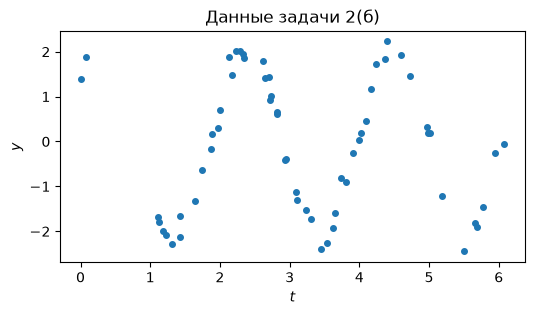

In [5]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ:**

A: $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ - нелинейная по параматрам модель, невыпукла.

При $x_3 \rightarrow x_3 + 2\pi$ функция не меняется: $\varphi_A(t; x = (x1, x2, x3)) = \varphi_A(t; x = (x1, x2, x_3 + 2\pi))$.

Аналогично при $(x_1, x_3) \rightarrow (-x_1, x_3 + \pi)$: $\varphi_A(t; x = (x1, x2, x3)) = \varphi_A(t; x = (-x1, x2, x_3 + \pi))$.

То есть разные параматры задают одну и ту же модель.

B: $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$, $\omega = 3$ - линейная по параметрам, выпукла.

Цель $f(x) = \tfrac12\sum_i \big(x_1 \sin\omega t + x_2 \cos\omega t - y_i\big)^2$. Каждая невязка является аффинной функцией от $x$, квадрат аффинной функции выпуклый, поэтому целевая функция (сумма выпуклых функций) также выпукла.

**Мультистарт (пункт 2)**

Модель A
 старт              ->  решение                                 f        success
[-1.86 -3.82  1.63] -> [-2.101 -2.997 -0.7  ]                   1.1393   True
[ 3.2  -0.27  0.58] -> [ 2.5929e+01 -2.0000e-03  4.0000e-03]   63.8249   False
[4.58 1.99 2.45]    -> [-2.101  2.997 -2.441]                   1.1393   True
[ 3.89 -2.84  1.5 ] -> [ 2.101 -2.997  2.441]                   1.1393   True
[ 2.17  3.42 -1.56] -> [2.101 2.997 0.7  ]                      1.1393   True
[ 1.89  1.04 -0.91] -> [-0.442  1.298  0.418]                  61.4973   True
[-3.98 -1.47  4.63] -> [0.442 1.298 3.559]                     61.4973   True
[-2.83 -3.86 -1.32] -> [ 0.101 -4.524 -1.335]                  64.2518   True
[-3.99 -2.33  4.14] -> [-2.101 -2.997  5.583]                   1.1393   True
[-1.81  0.86 -2.61] -> [-2.5994e+01 -2.0000e-03  3.1450e+00]   63.8249   False
[ 1.68 -3.72  2.9 ] -> [ 2.101 -2.997  2.441]                   1.1393   True
[-0.77 -3.16  2.58] -> [-2.101 -2.997 -0.7  ]     

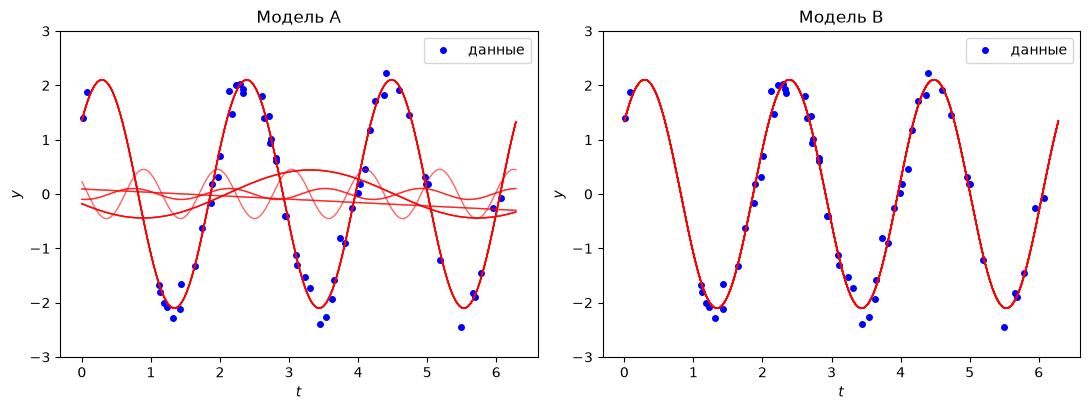

In [6]:
print("Модель A")
rA = lambda x: x[0] * np.sin(x[1] * t + x[2]) - y
fnA = lambda x: 0.5 * np.sum(rA(x) ** 2)
resA = [minimize(fnA, x0, method="BFGS") for x0 in starts]

print(" старт              ->  решение                                 f        success")
for x0, rr in zip(starts, resA):
    print(f"{x0.round(2)!s:19s} -> {rr.x.round(3)!s:37s} {rr.fun:9.4f}   {rr.success}")
print('-' * 80)
valsA = np.array([res.fun for res in resA])
print(f"Минимальное значение: {valsA.min():.6f}")
print(f"Доля стартов, пришедших к минимуму: {np.mean(np.isclose(valsA, valsA.min(), atol=1e-6)):.2%}")
print()


print("Модель B")
rB = lambda x: x[0] * np.sin(omega * t) + x[1] * np.cos(omega * t) - y
fnB = lambda x: 0.5 * np.sum(rB(x) ** 2)
resB = [minimize(fnB, x0[:2], method="BFGS") for x0 in starts]

print(" старт              ->  решение                                 f        success")
for x0, rr in zip(starts, resB):
    print(f"{x0.round(2)!s:19s} -> {rr.x.round(3)!s:37s} {rr.fun:9.4f}   {rr.success}")
print('-' * 80)
valsB = np.array([res.fun for res in resB])
print(f"Минимальное значение: {valsB.min():.6f}")
print(f"Доля стартов, пришедших к минимуму: {np.mean(np.isclose(valsB, valsB.min(), atol=1e-6)):.2%}")
print()


tt = np.linspace(0, 2 * np.pi, 500)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
ax.plot(t, y, "o", color="blue", ms=4, label="данные")
for rr in resA:
    ax.plot(tt, rr.x[0] * np.sin(rr.x[1] * tt + rr.x[2]), color="red", lw=1, alpha=0.6)
ax.set(title="Модель A", xlabel="$t$", ylabel="$y$", ylim=(-3, 3))
ax.legend(loc="upper right")

ax = axes[1]
ax.plot(t, y, "o", color="blue", ms=4, label="данные")
for rr in resB:
    ax.plot(tt, rr.x[0] * np.sin(omega * tt) + rr.x[1] * np.cos(omega * tt), color="red", lw=1, alpha=0.6)
ax.set(title="Модель B", xlabel="$t$", ylabel="$y$", ylim=(-3, 3))
ax.legend()
plt.tight_layout(); plt.show()

**Объяснение (пункт 3)**

**Ответ:**

Модель B является выпуклой задачей. По главной теореме лекции для выпуклой дифференцируемой задачи любой локальный минимум является глобальным. Поэтому все 20 стартов BFGS пришли к одной точке $x_B^\ast=(1.623, 1.338)$, и одному значению $f_B^\ast = 1.1408$.

Модель A невыпукла по параметрам, поэтому главная теорема не гарантирует, что локальный минимум является глобальным, что видно из результатов.

Модель B имеет вид $x_1\sin(3t) + x_2\cos(3t)$. Используя тождество $R\sin(3t + \phi) = R\sin(3t)\cos\phi + R\cos(3t)\sin\phi$ получаем $R\cos\phi = x_1, R\sin\phi = x_2$, откуда $R=\sqrt{x_1^2 + x_2^2}, \phi=\operatorname{atan2}(x_2, x_1)$. Численные значения для $x_B^\ast = (1.623, 1.338)$: $R \approx 2.103, \phi \approx 0.690$.

У A частота свободна, а у B она зафиксирована. Поэтому множество моделей A шире, чем множество моделей B, и минимум по A не может быть больше минимума по B: $f_A^\ast \le f_B^\ast$, что подтверждается полученными значениями.

Однако это не делает A «лучшей» задачей. A невыпуклая: разные старты могут приводить к разным локальным минимумам. B выпуклая и гарантирует глобальный минимум из любого стартового решения.

## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

**Ответ:** _(ваш текст; формулы — в $\LaTeX$)_

In [7]:
# ваш код


---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../CONTRIBUTING.md).